In [10]:
import os
import pandas as pd
import numpy as np
from dateutil.parser import parse
from datetime import timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import json
import textwrap

In [11]:
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

In [13]:
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))   # adjust if notebook location differs
RAW_PATH = os.path.join(ROOT, "data", "credit_rating_dataset.csv")
PROCESSED_DIR = os.path.join(ROOT, "data", "processed")
SCRIPTS_DIR = os.path.join(ROOT, "scripts")
REPORTS_DIR = os.path.join(ROOT, "reports")
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(SCRIPTS_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)


print("raw:", RAW_PATH)
print("processed:", PROCESSED_DIR)

raw: C:\vivek\TCS(psp)\data-mart-credit-rating-reporting\data\credit_rating_dataset.csv
processed: C:\vivek\TCS(psp)\data-mart-credit-rating-reporting\data\processed


In [14]:
df = pd.read_csv(RAW_PATH)
print("\nLoaded rows, cols:", df.shape)
display(df.head())



Loaded rows, cols: (1000, 8)


,Security Id,Vendor ID,Vendor Code,Source Feed ID,Rating Type,Exchange Code,Rating Date,Rating Code
0,TXU882Z,30,S&P,90,Long Term,LON,13-Aug-24,Baa1
1,MNQ991Y,10,Moodys,7,Long Term,LON,07-Sep-24,AA
2,UKS623JA,10,Moodys,7,Short Term,SGX,03-Jul-24,CC
3,MNQ991Y,20,Fitch,12,Short Term,NSE,12-Dec-24,Ba1
4,AM93THG,40,DBRS,44,Long Term,HKG,16-Apr-24,Baa1


In [15]:
print("\nData types:")
print(df.dtypes)
print("\nNull counts:")
print(df.isnull().sum())



Data types:
Security Id       object
Vendor ID          int64
Vendor Code       object
Source Feed ID     int64
Rating Type       object
Exchange Code     object
Rating Date       object
Rating Code       object
dtype: object

Null counts:
Security Id       0
Vendor ID         0
Vendor Code       0
Source Feed ID    0
Rating Type       0
Exchange Code     0
Rating Date       0
Rating Code       0
dtype: int64


In [16]:
def safe_parse_date(x):
    if pd.isna(x) or str(x).strip() == "":
        return pd.NaT
    for fmt in ("%Y-%m-%d", "%Y/%m/%d", "%d-%m-%Y", "%d/%b/%y", "%d-%b-%y", "%d-%b-%Y", "%d/%m/%Y", "%d-%b-%Y", "%d %b %Y", "%d %B %Y"):
        try:
            return pd.to_datetime(x, format=fmt)
        except:
            pass
    try:
        return parse(str(x), dayfirst=False, fuzzy=True)
    except:
        return pd.NaT

In [17]:
df.columns = [c.strip() for c in df.columns]
col_map = {
    # try to normalize to consistent internal names
    "Security Id": "security_id",
    "Vendor ID": "vendor_id",
    "Vendor Code": "vendor_code",
    "Source Feed ID": "source_feed_id",
    "Rating Type": "rating_type",
    "Exchange Code": "exchange_code",
    "Rating Date": "rating_date_raw",
    "Rating Code": "rating_code"
}
# apply mapping only for existing columns
rename_map = {c: col_map[c] for c in col_map if c in df.columns}
df = df.rename(columns=rename_map)

# After rename show columns
print("\nColumns after rename:", df.columns.tolist())


Columns after rename: ['security_id', 'vendor_id', 'vendor_code', 'source_feed_id', 'rating_type', 'exchange_code', 'rating_date_raw', 'rating_code']


In [18]:
str_cols = df.select_dtypes(include=["object"]).columns.tolist()
for c in str_cols:
    df[c] = df[c].astype(str).str.strip().replace({"": None, "nan": None, "NaN": None})

if "rating_code" not in df.columns and "Rating" in df.columns:
    df["rating_code"] = df["Rating"]

In [19]:
date_col = "rating_date_raw" if "rating_date_raw" in df.columns else None
if date_col:
    df["rating_date"] = df[date_col].apply(safe_parse_date)
    print(f"Parsed '{date_col}' -> rating_date (non-null count):", df["rating_date"].notna().sum())
else:
    df["rating_date"] = pd.NaT
    print("No date column found; rating_date set to NaT")

Parsed 'rating_date_raw' -> rating_date (non-null count): 1000


In [20]:
def detect_vendor(vendor_code, vendor_id):
    if pd.isna(vendor_code):
        return f"V{vendor_id}"
    vc = str(vendor_code).lower()
    if "mood" in vc or "moody" in vc:
        return "Moody's"
    if "s&p" in vc or "sp" in vc or "s&p" in vc.lower() or "s and p" in vc:
        return "S&P"
    if "fitch" in vc:
        return "Fitch"
    if "dbrs" in vc:
        return "DBRS"
    return vendor_code

if "vendor_code" in df.columns:
    df["vendor"] = df.apply(lambda r: detect_vendor(r.get("vendor_code"), r.get("vendor_id")), axis=1)
else:
    df["vendor"] = df["vendor_id"].apply(lambda x: f"V{x}")

In [21]:
sp_map = {
    "AAA":"AAA","AA+":"AA","AA":"AA","AA-":"AA","A+":"A","A":"A","A-":"A",
    "BBB+":"BBB","BBB":"BBB","BBB-":"BBB","BB":"BB","B":"B","CCC":"CCC","CC":"CC","C":"C","D":"D","NR":"UNRATED","NR.":"UNRATED"
}
moody_map = {
    "Aaa":"AAA","Aa1":"AA","Aa2":"AA","Aa3":"AA","A1":"A","A2":"A","A3":"A",
    "Baa1":"BBB","Baa2":"BBB","Baa3":"BBB","Ba1":"BB","Ba2":"BB","Ba3":"BB",
    "B1":"B","B2":"B","B3":"B","Caa":"CCC","Ca":"CC","C":"C","Not Rated":"UNRATED"
}
fitch_map = {
    "AAA":"AAA","AA":"AA","AA-":"AA","A+":"A","A":"A","A-":"A",
    "BBB+":"BBB","BBB":"BBB","BBB-":"BBB","BB+":"BB","BB":"BB","BB-":"BB","B":"B","CCC":"CCC","CC":"CC","C":"C","RD":"D"
}

df["rating_raw"] = df.get("rating_code").astype(str).str.strip()
df["rating_raw"] = df["rating_raw"].replace({"None": None, "nan": None, "NaN": None})

def map_to_standard(row):
    r = row["rating_raw"]
    vendor = row["vendor"]
    if pd.isna(r):
        return "UNRATED"
    r_str = str(r).strip()
    if "Moody" in str(vendor):
        return moody_map.get(r_str, r_str)
    if "S&P" in str(vendor) or "S&P" in str(row.get("vendor_code", "")):
        return sp_map.get(r_str, r_str)
    if "Fitch" in str(vendor):
        return fitch_map.get(r_str, r_str)
    return sp_map.get(r_str.upper(), r_str.upper())

df["standard_rating"] = df.apply(map_to_standard, axis=1)
df["standard_rating"] = df["standard_rating"].fillna("UNRATED")

In [22]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns.tolist()
if "security_id" in df.columns:
    df["security_id"] = df["security_id"].astype(str).str.strip()
else:
    df["security_id"] = df.index.astype(str).apply(lambda x: f"SEC_{x}")

In [23]:
print("Duplicates - before:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicates - after:", df.duplicated().sum())

df = df.sort_values(["security_id","vendor","rating_type","rating_date"])
df = df.drop_duplicates(subset=["security_id","vendor","rating_type","rating_date","rating_raw"], keep="last")


Duplicates - before: 0
Duplicates - after: 0


In [24]:
scd_rows = []
surrogate = 1

groupcols = ["security_id","vendor","rating_type"]
for key, grp in df.groupby(groupcols, sort=True):
    grp = grp.sort_values("rating_date").reset_index(drop=True)
    active_record = None
    for idx, row in grp.iterrows():
        start = row["rating_date"]
        rating = row["standard_rating"]
        source_feed = row.get("source_feed_id", None)
        if active_record is None:
            active_record = {
                "scd_key": surrogate,
                "security_id": row["security_id"],
                "vendor": row["vendor"],
                "rating_type": row["rating_type"],
                "rating": rating,
                "effective_start_date": start,
                "effective_end_date": pd.NaT,
                "is_active": 1,
                "source_feed_id": source_feed,
                "rating_raw": row["rating_raw"]
            }
            surrogate += 1
        else:
            # if rating unchanged, continue (no new scd row)
            if rating == active_record["rating"]:
                # optionally update other fields
                continue
            else:
                # expire previous active record one day before new start
                active_record["effective_end_date"] = (start - pd.Timedelta(days=1))
                active_record["is_active"] = 0
                scd_rows.append(active_record)
                # create new active
                active_record = {
                    "scd_key": surrogate,
                    "security_id": row["security_id"],
                    "vendor": row["vendor"],
                    "rating_type": row["rating_type"],
                    "rating": rating,
                    "effective_start_date": start,
                    "effective_end_date": pd.NaT,
                    "is_active": 1,
                    "source_feed_id": source_feed,
                    "rating_raw": row["rating_raw"]
                }
                surrogate += 1
    if active_record is not None:
        # finalize last record (still active)
        scd_rows.append(active_record)

ratings_type2 = pd.DataFrame(scd_rows)
print("\nSCD Type-2 sample rows:", len(ratings_type2))
display(ratings_type2.head(10))


SCD Type-2 sample rows: 966


,scd_key,security_id,vendor,rating_type,rating,effective_start_date,effective_end_date,is_active,source_feed_id,rating_raw
0,1,AM93THG,DBRS,Long Term,BBB,2024-01-09,2024-02-09,0,44,BBB
1,2,AM93THG,DBRS,Long Term,CCC-,2024-02-10,2024-02-29,0,44,CCC-
2,3,AM93THG,DBRS,Long Term,B3,2024-03-01,2024-04-15,0,44,B3
3,4,AM93THG,DBRS,Long Term,BAA1,2024-04-16,2024-06-06,0,44,Baa1
4,5,AM93THG,DBRS,Long Term,BB,2024-06-07,2024-08-13,0,44,BB
5,6,AM93THG,DBRS,Long Term,C,2024-08-14,2024-08-14,0,44,C
6,7,AM93THG,DBRS,Long Term,A2,2024-08-15,2024-09-02,0,44,A2
7,8,AM93THG,DBRS,Long Term,BBB,2024-09-03,2024-09-05,0,44,BBB-
8,9,AM93THG,DBRS,Long Term,B2,2024-09-06,NaT,1,44,B2
9,10,AM93THG,DBRS,Short Term,BA3,2024-01-23,2024-02-26,0,44,Ba3


In [25]:
df_tx = df.copy()
df_tx["year"] = df_tx["rating_date"].dt.year
# compute changes by comparing each row with previous for same key
df_tx = df_tx.sort_values(["security_id","vendor","rating_type","rating_date"])
df_tx["prev_rating"] = df_tx.groupby(["security_id","vendor","rating_type"])["standard_rating"].shift(1)
df_tx["is_change"] = (df_tx["standard_rating"] != df_tx["prev_rating"]).astype(int)
df_tx.loc[df_tx["prev_rating"].isna(), "is_change"] = 1  # treat first seen as change/initial

rating_freq = df_tx.groupby(["vendor","year"])["is_change"].sum().reset_index().rename(columns={"is_change":"rating_change_count"})
print("\nRating freq sample:")
display(rating_freq.head())


Rating freq sample:


,vendor,year,rating_change_count
0,CARE,2024,76
1,CARE,2025,43
2,DBRS,2024,116
3,Fitch,2024,133
4,ICRA,2024,75


In [27]:

scale_order = {
    "AAA":0, "AA":1, "A":2, "BBB":3, "BB":4, "B":5,
    "CCC":6, "CC":7, "C":8, "D":9, "UNRATED":10
}

df_tx["rating_score"] = df_tx["standard_rating"].map(scale_order).fillna(10).astype(int)

pivot = df_tx.pivot_table(
    index=["security_id", "rating_date", "rating_type"],
    columns="vendor",
    values="rating_score",
    aggfunc="first"
).reset_index()

vendor_score_cols = [c for c in pivot.columns if c not in ["security_id", "rating_date", "rating_type"]]

pivot["score_min"] = pivot[vendor_score_cols].min(axis=1, skipna=True)
pivot["score_max"] = pivot[vendor_score_cols].max(axis=1, skipna=True)

pivot["score_diff"] = (pivot["score_max"] - pivot["score_min"]).fillna(0)

pivot["is_outlier"] = (pivot["score_diff"] >= 2).astype(int)

outlier_pct_by_date = (
    pivot.groupby("rating_date")["is_outlier"]
    .mean()
    .reset_index()
    .rename(columns={"is_outlier": "outlier_pct"})
)

print("\n Outlier Detection Completed – Sample:")
display(pivot.head())
print("\n Outlier Percentage by Date:")
display(outlier_pct_by_date.head())



 Outlier Detection Completed – Sample:


vendor,security_id,rating_date,rating_type,CARE,DBRS,Fitch,ICRA,Kroll,Moody's,Morningstar,S&P,score_min,score_max,score_diff,is_outlier
0,AM93THG,2024-01-06,Short Term,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,7.0,7.0,0.0,0
1,AM93THG,2024-01-09,Long Term,NaN,3.0,10.0,NaN,NaN,NaN,NaN,NaN,3.0,10.0,7.0,1
2,AM93THG,2024-01-23,Short Term,NaN,10.0,NaN,NaN,NaN,NaN,NaN,NaN,10.0,10.0,0.0,0
3,AM93THG,2024-01-25,Long Term,NaN,NaN,10.0,NaN,NaN,NaN,NaN,NaN,10.0,10.0,0.0,0
4,AM93THG,2024-01-26,Short Term,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,4.0,4.0,0.0,0



 Outlier Percentage by Date:


,rating_date,outlier_pct
0,2024-01-01,0.0
1,2024-01-04,0.0
2,2024-01-06,0.0
3,2024-01-08,0.5
4,2024-01-09,0.5


In [28]:
def compute_precision(row):
    vals = [row[c] for c in vendor_score_cols if pd.notna(row[c])]
    if len(vals) <= 1:
        return 1.0
    # map back to rating string or compare identical values
    from collections import Counter
    most_common = Counter(vals).most_common(1)[0][1]
    return most_common / len(vals)

pivot["precision"] = pivot.apply(compute_precision, axis=1)

In [29]:
df.to_csv(os.path.join(PROCESSED_DIR, "transactions_cleaned.csv"), index=False)
ratings_type2.to_csv(os.path.join(PROCESSED_DIR, "ratings_type2_sample.csv"), index=False)
rating_freq.to_csv(os.path.join(PROCESSED_DIR, "rating_frequency_per_vendor_year.csv"), index=False)
pivot[['security_id','rating_date','rating_type','score_diff','is_outlier','precision']].to_csv(
    os.path.join(PROCESSED_DIR, "outlier_precision_by_security_date.csv"), index=False)

print("\nSaved processed CSVs to:", PROCESSED_DIR)
print(os.listdir(PROCESSED_DIR))


Saved processed CSVs to: C:\vivek\TCS(psp)\data-mart-credit-rating-reporting\data\processed
['outlier_precision_by_security_date.csv', 'ratings_type2_sample.csv', 'rating_frequency_per_vendor_year.csv', 'transactions_cleaned.csv']


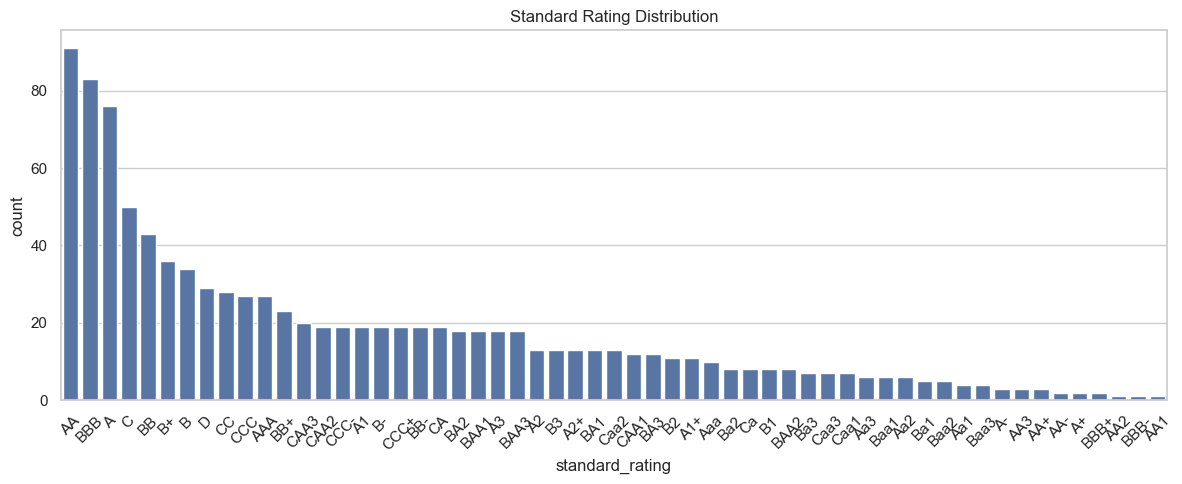

In [30]:
sns.set(style="whitegrid")
# A: Rating distribution (standard_rating)
plt.figure(figsize=(12,5))
order = df["standard_rating"].value_counts().index
sns.countplot(data=df, x="standard_rating", order=order)
plt.title("Standard Rating Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

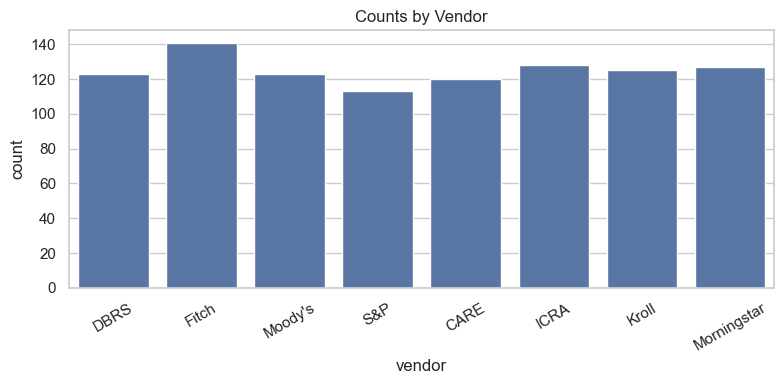

In [31]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="vendor")
plt.title("Counts by Vendor")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

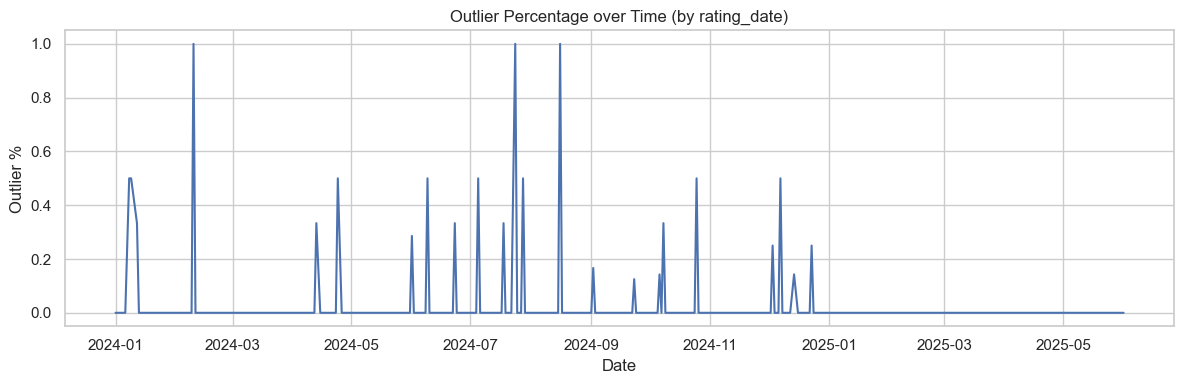

In [32]:
if not outlier_pct_by_date.empty:
    plt.figure(figsize=(12,4))
    outlier_pct_by_date = outlier_pct_by_date.sort_values("rating_date")
    plt.plot(outlier_pct_by_date['rating_date'], outlier_pct_by_date['outlier_pct'])
    plt.title("Outlier Percentage over Time (by rating_date)")
    plt.ylabel("Outlier %")
    plt.xlabel("Date")
    plt.tight_layout()
    plt.show()

In [33]:
test_cases = [
    ["TC01","1","Power BI Report","Verify rating trends line chart","Data loaded and cleaned","transactions_cleaned.csv","1","Validate rating codes vs mapping","Line chart plotted","N"],
    ["TC02","1","ETL Script","Verify SCD type2 population","transactions_cleaned.csv","ratings_type2_sample.csv","1","Check active flags and dates","N"]
]
test_df = pd.DataFrame(test_cases, columns=[
    "Test Case #","Step #","Application/Screen","Test Case Description","Pre-Requisites","Input Data","Iteration #","Cross Validation","Expected Result","Defect(Y/N)"
])
test_df.to_csv(os.path.join(REPORTS_DIR, "test_cases_template.csv"), index=False)

# Test Scenario template
scenario_df = pd.DataFrame([["REQ01","TS01","Power BI Dashboard","Visualize vendor rating comparison","Key metrics visible","High"]],
                           columns=["Req Id","Test Scenario Id","Application/Screen","High Level Test Conditions","Expected Results","Priority"])
scenario_df.to_csv(os.path.join(REPORTS_DIR, "test_scenarios_template.csv"), index=False)

print("\nSaved test templates to:", REPORTS_DIR)


Saved test templates to: C:\vivek\TCS(psp)\data-mart-credit-rating-reporting\reports


In [34]:
deliverables = {
    "processed_files": [
        os.path.join("data","processed","transactions_cleaned.csv"),
        os.path.join("data","processed","ratings_type2_sample.csv"),
        os.path.join("data","processed","rating_frequency_per_vendor_year.csv"),
        os.path.join("data","processed","outlier_precision_by_security_date.csv")
    ],
    "test_templates": [
        os.path.join("reports","test_cases_template.csv"),
        os.path.join("reports","test_scenarios_template.csv")
    ],
    "notebook": os.path.join("notebooks","project_full_pipeline.ipynb"),
    "readme": "README_project.md"
}
with open(os.path.join(ROOT, "deliverables_manifest.json"), "w") as f:
    json.dump(deliverables, f, indent=2)

print("\nDeliverables manifest created at:", os.path.join(ROOT, "deliverables_manifest.json"))


Deliverables manifest created at: C:\vivek\TCS(psp)\data-mart-credit-rating-reporting\deliverables_manifest.json


In [35]:
readme_text = textwrap.dedent(f"""
# Data Mart Loading & Credit Rating Reporting - Project Deliverables

This folder contains processed outputs and templates generated from the notebook 'project_full_pipeline.ipynb'.

## Files generated
- data/processed/transactions_cleaned.csv : Cleaned transaction-level staging data
- data/processed/ratings_type2_sample.csv : Sample SCD Type-2 ratings table
- data/processed/rating_frequency_per_vendor_year.csv : KPI - rating change frequency
- data/processed/outlier_precision_by_security_date.csv : KPI - outlier percentage and precision
- reports/test_cases_template.csv : Test case template CSV
- reports/test_scenarios_template.csv : Test scenario template CSV
- deliverables_manifest.json : Manifest of generated deliverables

## How to use
1. Use ratings_type2_sample.csv to populate dimension/history tables in your data mart (SCD Type-2).
2. Use KPI CSVs as direct sources for Power BI / Tableau dashboards.

""")
with open(os.path.join(ROOT, "README_project.md"), "w") as f:
    f.write(readme_text)

print("\nREADME_project.md created.")


README_project.md created.


In [36]:


script_content = textwrap.dedent("""
import pandas as pd
import os

def build_type2(staging_csv, out_csv):
    df = pd.read_csv(staging_csv, parse_dates=['rating_date'])
    df = df.sort_values(['security_id','vendor','rating_type','rating_date'])
    rows = []
    surrogate = 1
    for (sec, ven, rtype), grp in df.groupby(['security_id','vendor','rating_type']):
        grp = grp.sort_values('rating_date')
        active = None
        for _, r in grp.iterrows():
            rating = r['standard_rating']
            start = r['rating_date']
            if active is None:
                active = {'scd_key':surrogate,'security_id':sec,'vendor':ven,'rating_type':rtype,'rating':rating,'effective_start_date':start,'effective_end_date':None,'is_active':1}
                surrogate += 1
            else:
                if rating == active['rating']:
                    continue
                else:
                    active['effective_end_date'] = start - pd.Timedelta(days=1)
                    active['is_active'] = 0
                    rows.append(active)
                    active = {'scd_key':surrogate,'security_id':sec,'vendor':ven,'rating_type':rtype,'rating':rating,'effective_start_date':start,'effective_end_date':None,'is_active':1}
                    surrogate += 1
        if active:
            rows.append(active)
    out = pd.DataFrame(rows)
    out.to_csv(out_csv, index=False)
    print('SCD written to', out_csv)

if __name__ == '__main__':
    root = os.path.abspath(os.path.join(os.path.dirname(__file__), '..'))
    staging = os.path.join(root, 'data','processed','transactions_cleaned.csv')
    out = os.path.join(root, 'data','processed','ratings_type2_sample_from_script.csv')
    build_type2(staging, out)
""")
with open(os.path.join(SCRIPTS_DIR, "prepare_scd.py"), "w") as f:
    f.write(script_content)

print("\nHelper script scripts/prepare_scd.py written.")


print("\n=== Pipeline run complete ===")
print("Check folder:", PROCESSED_DIR, "and", REPORTS_DIR)


Helper script scripts/prepare_scd.py written.

=== Pipeline run complete ===
Check folder: C:\vivek\TCS(psp)\data-mart-credit-rating-reporting\data\processed and C:\vivek\TCS(psp)\data-mart-credit-rating-reporting\reports
